# LOTA training walkthrough

Cell-by-cell version of `train.py`, so each stage (config, preprocessing/data, model init, one training epoch, validation) can be run and re-run independently.

Run this notebook from the repo root (same directory as `train.py`) so the relative imports and `../GenImage_root` path resolve exactly as they do for the CLI script.

## Setup

In [27]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

import types
import torch
from PIL import ImageFile, Image
import numpy as np
import cv2
import cv2 as cv
import random
from torchvision.transforms import transforms
import matplotlib.pyplot as plt
ImageFile.LOAD_TRUNCATED_IMAGES = True
from torch.utils.data import Dataset, DataLoader
import util as toolkit
from loader import get_loader as fetch_train_data, get_val_loader as fetch_val_data, MODEL_NAME_MAP
from model import model as NeuralNetwork
from util import bceLoss as compute_binary_loss
from time import time
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

CUDA available: True
CUDA device: NVIDIA GeForce GTX 1080 Ti


## Config

Same fields/defaults as `config.py`, but built by hand as a `SimpleNamespace` instead of via `argparse` (argparse would try to parse Jupyter's own `sys.argv`). Edit values here directly instead of passing CLI flags.

This mirrors: `python train.py --choice 0 0 0 0 0 0 1 0 --image_root ../GenImage_root --bit_mode thresholding --patch_size 32 --patch_mode max`

In [2]:
config = types.SimpleNamespace(
    batchsize=64,
    choices=[0, 0, 0, 1, 0, 0, 0, 0],   # index 6 -> GLIDE
    epoch=30,
    lr=0.0001,
    load=None,                          # path to a checkpoint to resume from, or None
    image_root="../GenImage_root",
    isPatch=True,
    img_height=256,
    bit_mode="scaling",
    patch_size=32,
    patch_mode="max",
    gpu_id="0",
    val_batchsize=64,
    unbiased=False,
)

config.isTrain = True
config.isVal = False

if config.unbiased:
    config.qf = 96

unbiased_suffix = '_unbiased' if config.unbiased else ''
qf_subdir = f'qf{config.qf}/' if config.unbiased else ''
active_subsets = [MODEL_NAME_MAP[i] for i, flag in enumerate(config.choices) if flag]
subset_subdir = '+'.join(active_subsets) if active_subsets else 'none'
config.save_path = (
    f'../weights{unbiased_suffix}/{subset_subdir}/'
    f'{config.bit_mode}/{config.patch_mode}/{qf_subdir}'
)

val_config = types.SimpleNamespace(**vars(config))
val_config.isTrain = False
val_config.isVal = True

os.makedirs(config.save_path, exist_ok=True)
print("save_path:", config.save_path)
for k, v in sorted(vars(config).items()):
    print(f"  {k}: {v}")

save_path: ../weights/Stable_Diffusion_v1.4/scaling/max/
  batchsize: 64
  bit_mode: scaling
  choices: [0, 0, 0, 1, 0, 0, 0, 0]
  epoch: 30
  gpu_id: 0
  image_root: ../GenImage_root
  img_height: 256
  isPatch: True
  isTrain: True
  isVal: False
  load: None
  lr: 0.0001
  patch_mode: max
  patch_size: 32
  save_path: ../weights/Stable_Diffusion_v1.4/scaling/max/
  unbiased: False
  val_batchsize: 64


## Preprocessing / data loading

Builds the train/val `DataLoader`s. The preprocessing itself (bit-mode transform, patch extraction via `bit_patch`, `ToTensor`, ImageNet normalization) is wired up inside `get_loader`/`get_val_loader` -> `create_preprocessing_pipeline` (see `loader.py`); this cell is where it's actually invoked (dataset construction + first batch pull below trigger it).

In [3]:
train_loader = fetch_train_data(config)
val_loader = fetch_val_data(val_config)

print(f"Train batches per epoch: {len(train_loader)} (batchsize={config.batchsize})")
for entry in val_loader:
    print(f"Val set: {entry['name']:<24} nature={entry['nature_size']:<6} ai={entry['ai_size']}")

Train dataset: Stable_Diffusion_v1.4
Dataset size: 162000 (natural) 161997 (AI)
Val dataset: Stable_Diffusion_v1.4
Dataset size: 6000 (natural) 6000 (AI)
Train batches per epoch: 5063 (batchsize=64)
Val set: Stable_Diffusion_v1.4    nature=6000   ai=6000


### (optional) Visualize a preprocessed sample

Pulls one training batch and un-normalizes the first image, so you can see exactly what the model receives: the upsampled 32x32 patch selected by `bit_patch` (see prior discussion — `bit_mode='thresholding'` is currently a no-op passthrough).

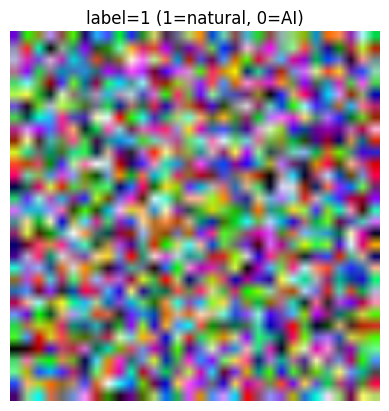

In [4]:
import matplotlib.pyplot as plt

sample_inputs, sample_labels = next(iter(train_loader))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img = (sample_inputs[0] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

plt.imshow(img)
plt.title(f"label={sample_labels[0].item():.0f} (1=natural, 0=AI)")
plt.axis("off")
plt.show()

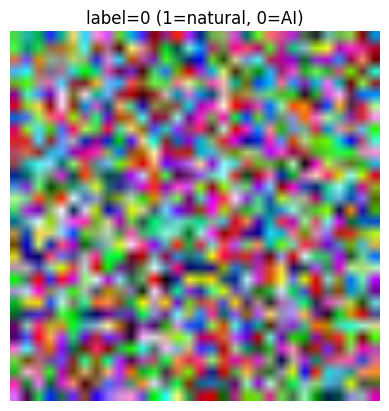

In [5]:
n = 3
img = (sample_inputs[n] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
plt.imshow(img)
plt.title(f"label={sample_labels[n].item():.0f} (1=natural, 0=AI)")
plt.axis("off")
plt.show()

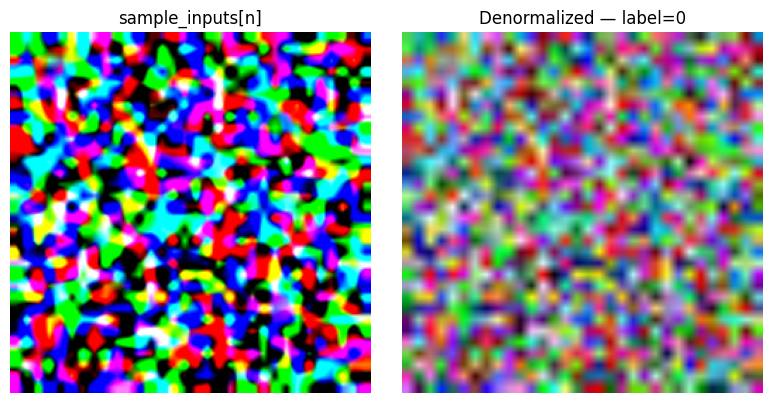

In [6]:
n = 3

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Original normalized input (as stored in sample_inputs)
axes[0].imshow(sample_inputs[n].clamp(0,1).permute(1, 2, 0).numpy())
axes[0].set_title("sample_inputs[n]")
axes[0].axis("off")

# Denormalized input
img = (sample_inputs[n] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
axes[1].imshow(img)
axes[1].set_title(f"Denormalized — label={sample_labels[n].item():.0f}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Debug Bit Patch

Loading: ../GenImage_root/Stable_Diffusion_v1.4/train/nature/n01440764_10043.JPEG


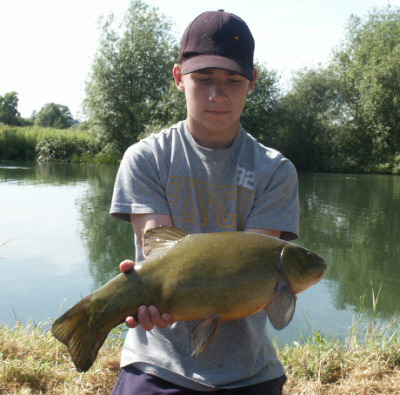

In [7]:
def load_single_image(image_root, dataset_name, category, split="train", index=0):
    """Grab one raw image the same way GenerativeImage{Training,Validation}Set
    locates images, without building the full dataset."""
    img_dir = os.path.join(image_root, dataset_name, split, category)
    filenames = sorted(os.listdir(img_dir))
    img_path = os.path.join(img_dir, filenames[index])
    print(f"Loading: {img_path}")
    return Image.open(img_path).convert("RGB")


single_img = load_single_image(config.image_root, active_subsets[0], 'nature')
single_img

In [8]:
def two_imgshow(a, b, at = '', bt = ''):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # Original normalized input (as stored in sample_inputs)
    axes[0].imshow(a)
    axes[0].set_title(at)
    axes[0].axis("off")
    
    # Denormalized input
    axes[1].imshow(b)
    axes[1].set_title(bt)
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

def compute(patch):
    patch = np.array(patch).astype(np.int64)
    diff_horizontal = np.sum(np.abs(patch[:, :-1, :] - patch[:, 1:, :]))
    diff_vertical = np.sum(np.abs(patch[:-1, :, :] - patch[1:, :, :]))
    diff_diagonal = np.sum(np.abs(patch[:-1, :-1, :] - patch[1:, 1:, :]))
    diff_diagonal += np.sum(np.abs(patch[1:, :-1, :] - patch[:-1, 1:, :]))
    res = diff_horizontal + diff_vertical + diff_diagonal
    return res.sum()

def bit_patch(img, img_height, bit_mode, patch_size, patch_mode, interpolation=cv2.INTER_LINEAR):
    img_np = np.array(img)
    #combined_image = None
    if bit_mode == "scaling":
        mask_low = 0x07
        red_low3 = ((img_np[:, :, 0] & mask_low) * (255 // 7)).astype(np.uint8)
        green_low3 = ((img_np[:, :, 1] & mask_low) * (255 // 7)).astype(np.uint8)
        blue_low3 = ((img_np[:, :, 2] & mask_low) * (255 // 7)).astype(np.uint8)
        combined_image = cv.merge((red_low3, green_low3, blue_low3))
    elif bit_mode == "thresholding":
        mask_low = 0x07
        red_low3 = img_np[:, :, 0] & mask_low
        green_low3 = img_np[:, :, 1] & mask_low
        blue_low3 = img_np[:, :, 2] & mask_low
        red_thresh = np.where(red_low3 > 0, 255, 0).astype(np.uint8)
        green_thresh = np.where(green_low3 > 0, 255, 0).astype(np.uint8)
        blue_thresh = np.where(blue_low3 > 0, 255, 0).astype(np.uint8)
        combined_image = cv.merge((red_thresh, green_thresh, blue_thresh))
    else:
        raise ValueError(f"Unsupported bit_mode: {bit_mode}")
    h, w, _ = combined_image.shape
    
    combined_image = Image.fromarray(combined_image)
    two_imgshow(img_np, combined_image, 'Unprocessed', bit_mode)
    min_len = min(h, w)
    rz = transforms.Resize((img_height, img_height))
    if min_len < patch_size:
        combined_image = rz(combined_image)
    num_patch = (img_height // patch_size) ** 2
    patch_list = []
    rp = transforms.RandomCrop(patch_size)
    for _ in range(num_patch):
        patch_list.append(rp(combined_image))

    if patch_mode == "max":
        patch_list.sort(key=lambda x: compute(x), reverse=True)
        selected_patch = patch_list[0]
    elif patch_mode == "min":
        patch_list.sort(key=lambda x: compute(x), reverse=False)
        selected_patch = patch_list[0]
    else:
        selected_patch = random.choice(patch_list)

    patch_np = np.array(selected_patch)
    return cv2.resize(patch_np, (img_height, img_height), interpolation = interpolation), patch_np, patch_list

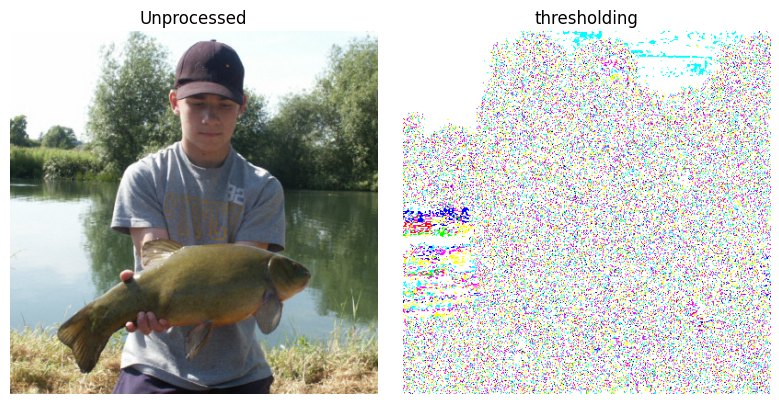

In [11]:
patch, raw_patch, _ = bit_patch(single_img, 256, 'thresholding', 32, 'max', interpolation = cv2.INTER_NEAREST)

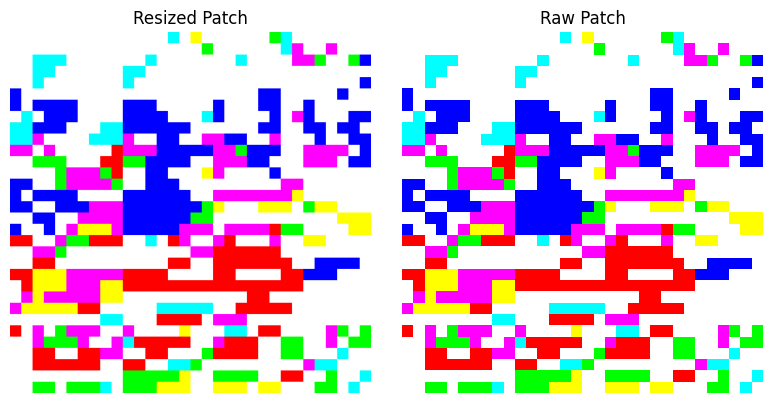

In [12]:
two_imgshow(patch, raw_patch, 'Resized Patch', 'Raw Patch')

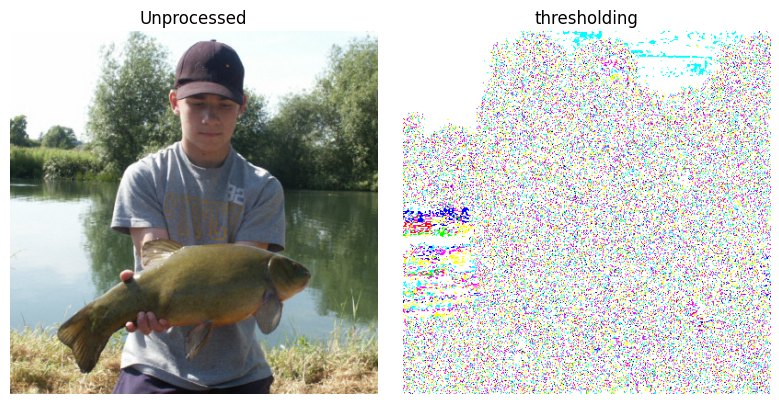

In [14]:
patch, raw_patch, _ = bit_patch(single_img, 256, 'thresholding', 32, 'max')

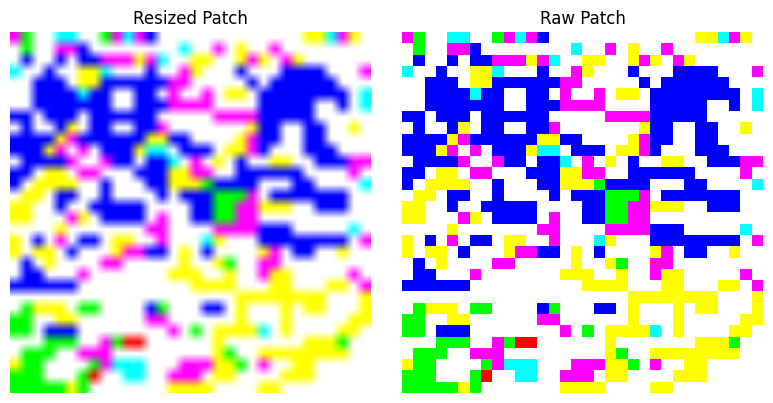

In [15]:
two_imgshow(patch, raw_patch, 'Resized Patch', 'Raw Patch')

## AI images and Regular images next to eachother

In [16]:
def plot_images(images):
    fig, axes = plt.subplots(8, 8, figsize=(12, 12))

    for ax, img in zip(axes.flat, images):
        ax.imshow(img)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

single_img_nature = load_single_image(config.image_root, active_subsets[0], 'nature')
single_img_ai = load_single_image(config.image_root, active_subsets[0], 'ai')

Loading: ../GenImage_root/Stable_Diffusion_v1.4/train/nature/n01440764_10043.JPEG
Loading: ../GenImage_root/Stable_Diffusion_v1.4/train/ai/000_sdv4_00000.png


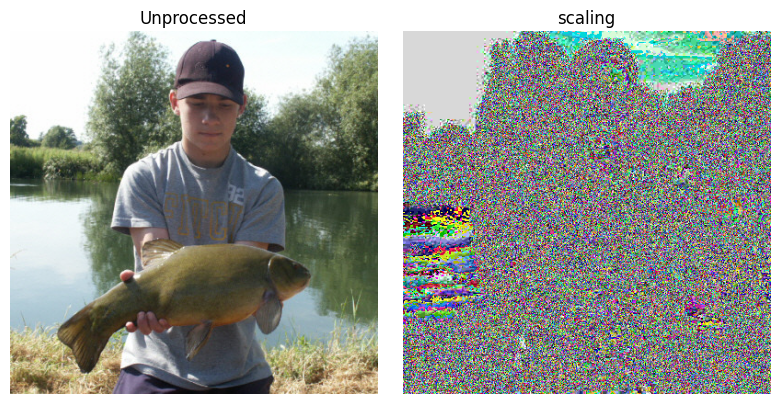

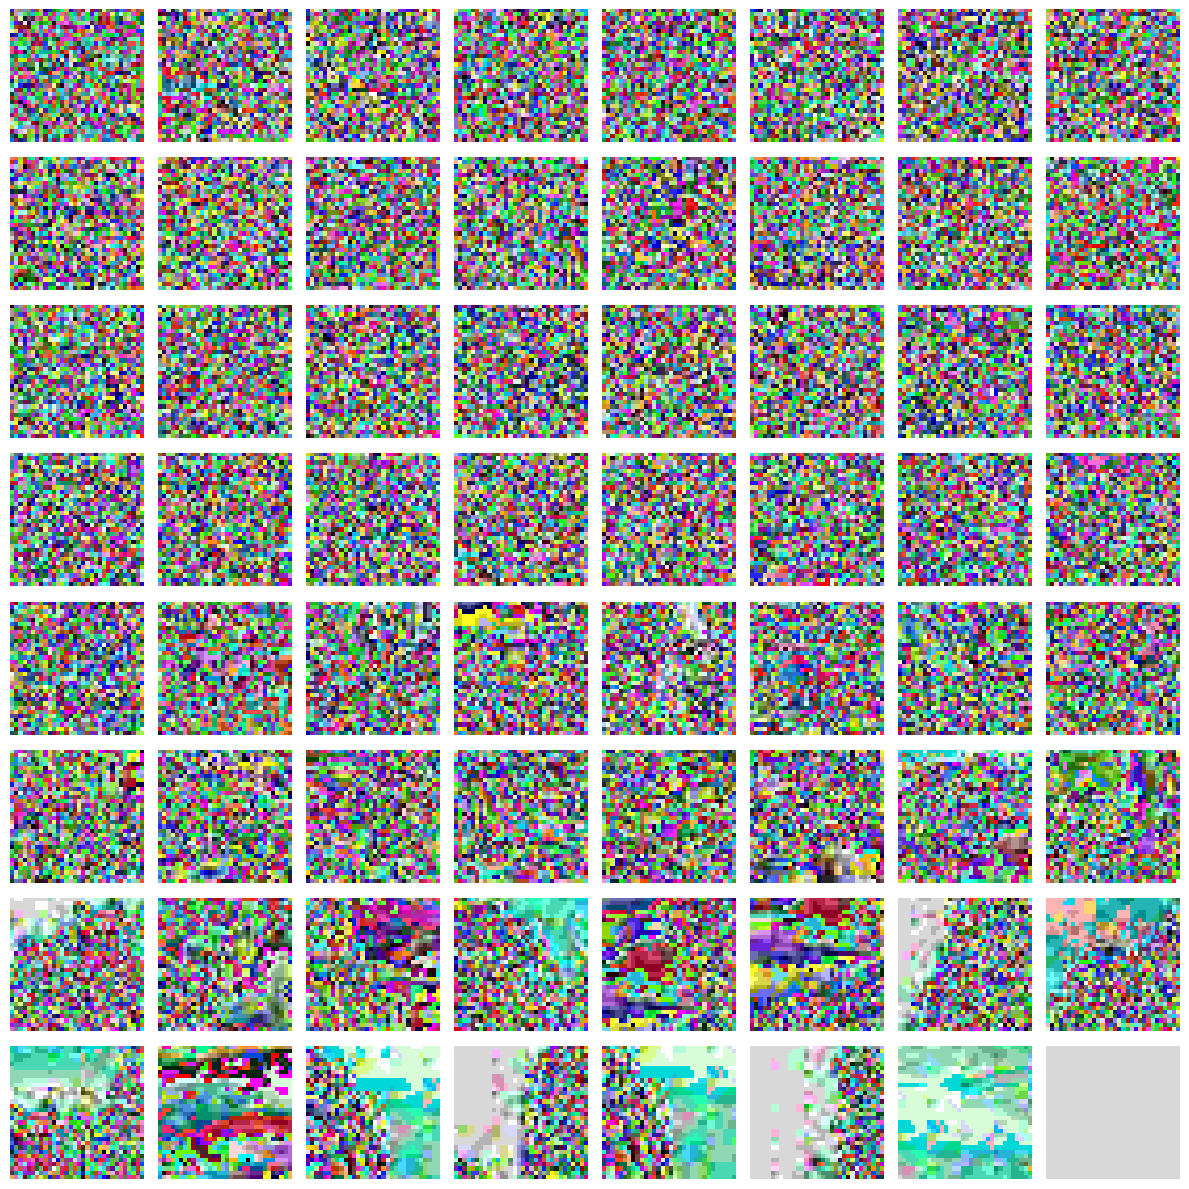

In [17]:
### NATURE
patch_nature, raw_patch_nature, patch_list_nature = bit_patch(single_img_nature, 256, 'scaling', 32, 
                                                              'max', interpolation = cv2.INTER_NEAREST)
plot_images(patch_list_nature)

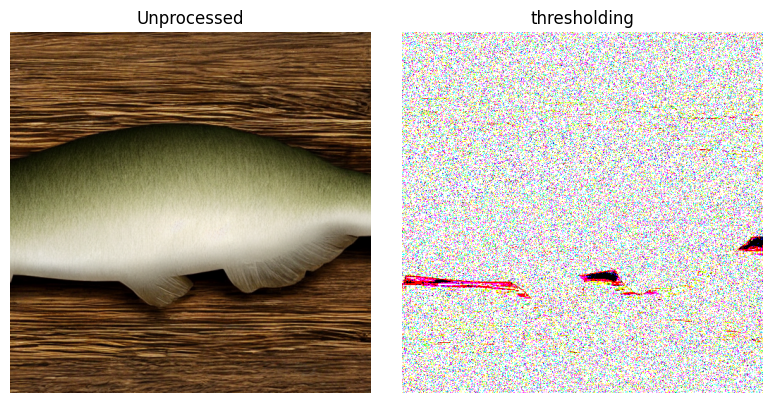

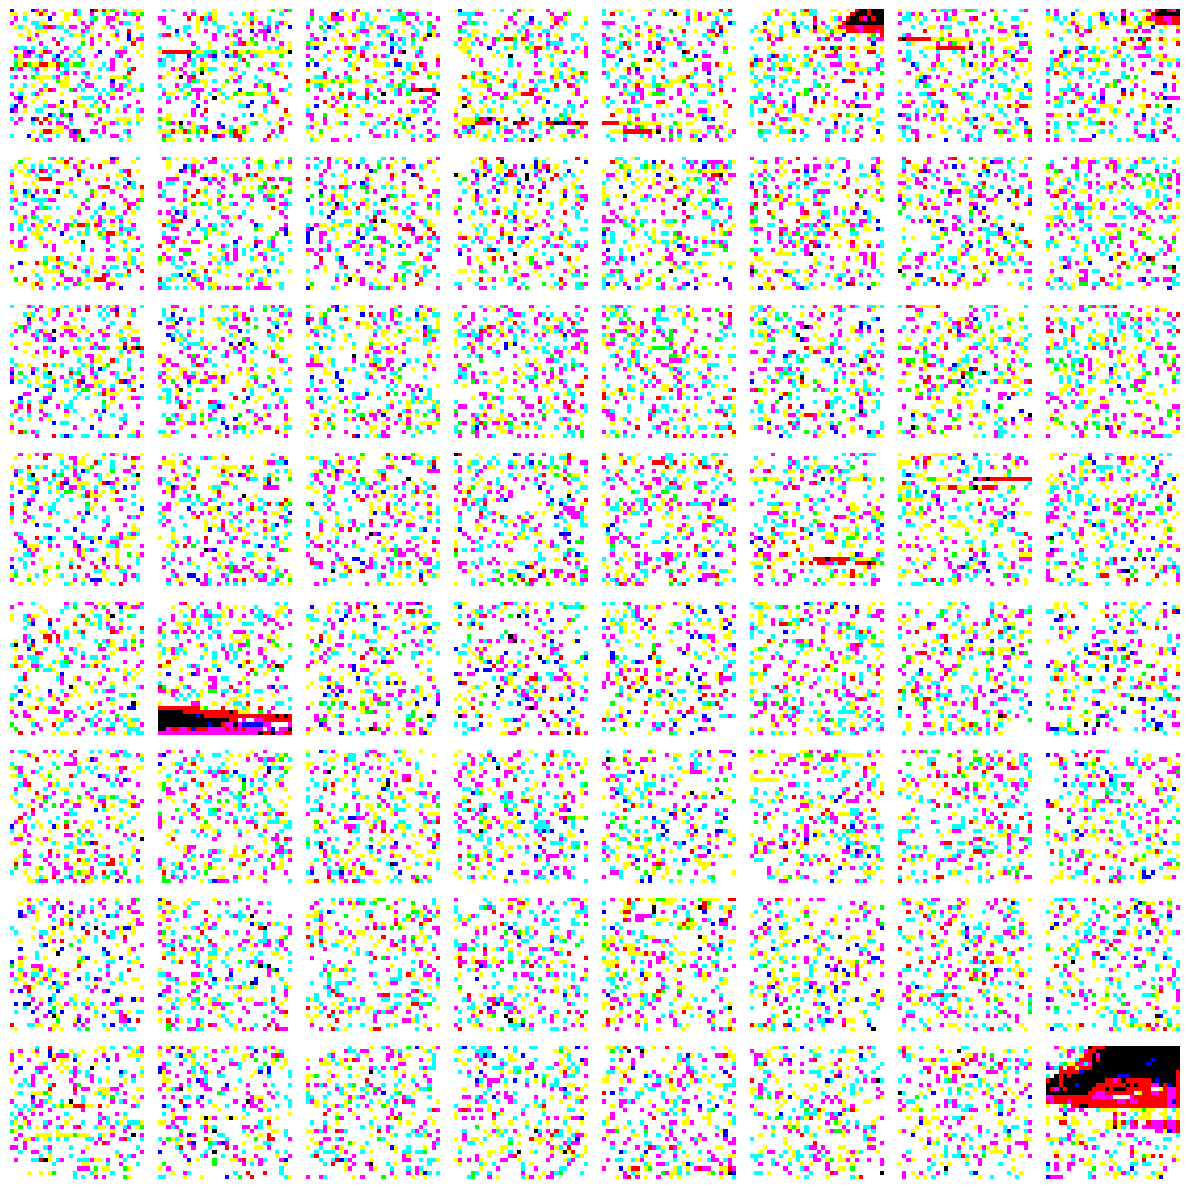

In [18]:
### AI
patch_ai, raw_patch_ai, patch_list_ai = bit_patch(single_img_ai, 256, 'thresholding', 32, 
                                           'max', interpolation = cv2.INTER_NEAREST)
plot_images(patch_list_ai)

## Model & optimizer

In [20]:
model_net = NeuralNetwork().cuda()

if config.load:
    model_net.load_state_dict(torch.load(config.load))
    print(f"Loaded model from {config.load}")

optimizer = torch.optim.Adam(model_net.parameters(), config.lr)

best_performing_epoch = 0
highest_accuracy = 0

config_path = toolkit.save_config(config, config.save_path)
print(f"Saved config to {config_path}")

Saved config to ../weights/Stable_Diffusion_v1.4/scaling/max/config.json


## Train one epoch

Re-run this cell to train the next epoch (it keeps an `current_epoch` counter across reruns and applies the same `poly_lr` schedule `train.py` uses). Restart the kernel / rerun the model cell above to start over from epoch 1.

In [21]:
def _train_one_epoch(epoch_index):
    model_net.train()
    total_loss = 0.0
    epoch_iterations = 0

    current_lr = toolkit.poly_lr(optimizer, config.lr, epoch_index, config.epoch)
    print(f"Epoch {epoch_index} | lr={current_lr:.6f}")
    start = time()
    for batch_idx, (inputs, targets) in enumerate(train_loader, start=1):
        optimizer.zero_grad()
        inputs = inputs.cuda()
        targets = targets.cuda()
        outputs = model_net(inputs).ravel()
        loss_function = compute_binary_loss()
        batch_loss = loss_function(outputs, targets)
        
        batch_loss.backward()
        optimizer.step()
        epoch_iterations += 1
        total_loss += batch_loss.item()

        end = time()
        if batch_idx % 10 == 0 or batch_idx == len(train_loader) or batch_idx == 1:
            print(f"  iter {batch_idx:04d}/{len(train_loader):04d} | loss={batch_loss.item():.6f} | time={end-start:.3f}")
            start = time()
    avg_loss = total_loss / max(epoch_iterations, 1)
    print(f"Epoch {epoch_index} done | avg_loss={avg_loss:.6f}")

    if epoch_index % 50 == 0:
        checkpoint_path = os.path.join(config.save_path, f'Network_epoch_{epoch_index}.pth')
        torch.save(model_net.state_dict(), checkpoint_path)
        print(f"Saved checkpoint to {checkpoint_path}")

    return avg_loss

del current_epoch
if 'current_epoch' not in globals():
    current_epoch = -1
current_epoch += 1

#avg_loss = _train_one_epoch(current_epoch)

NameError: name 'current_epoch' is not defined

### Trying to remodel training loader within this cell

In [33]:
def get_loader(opt):
    return create_training_loader(opt)

def create_training_loader(options):
    choices = options.choices
    root_dir = options.image_root

    datasets = []

    dataset_config = [
        (0, "BigGAN"),
        (1, "Midjourney"),
        (2, "Wukong"),
        (3, "Stable_Diffusion_v1.4"),
        (4, "Stable_Diffusion_v1.5"),
        (5, "ADM"),
        (6, "GLIDE"),
        (7, "VQDM")
    ]

    for idx, folder_name in dataset_config:
        if choices[idx]:
            print(f"Train dataset: {MODEL_NAME_MAP[idx]}")
            dataset = GenerativeImageTrainingSet(
                root_dir, folder_name, options
            )
            datasets.append(dataset)
            
            
    combined_dataset = torch.utils.data.ConcatDataset(datasets)

    return DataLoader(
        combined_dataset,
        batch_size=options.batchsize,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )

class GenerativeImageTrainingSet(Dataset):
    ### het enige wat je hoeft aan te passen is de _load_images functie, die moet een lijst met image paths maken.
    def __init__(self, root_dir, dataset_name, options):
        super().__init__()
        self.options = options
        
        ## GenImage_root, Wukong, train
        self.base_path = os.path.join(root_dir, dataset_name, "train")

        if not self.options.unbiased:
            self.natural_images = self._load_images("nature")
            self.ai_images = self._load_images("ai")
        if self.options.unbiased:
            df_unbiased_natural, df_unbiased_ai = retrieve_unbiased_dataset(dataset_name, 'train')
            self.natural_images = df_unbiased_natural['path'].tolist()
            self.ai_images = df_unbiased_ai['path'].tolist()
            print("loaded metadata.csv")

            ### load df of this particular category
            ### filter out the train images
            ### create a list of all these paths
            #1024×1024 (MJ), 512×512 (SD4, SD5, Wukong), 256×256 (GLIDE, ADM, VQDM), and 128×128
        self.all_images = self.natural_images + self.ai_images
        self.labels = torch.cat([
            torch.ones(len(self.natural_images)),
            torch.zeros(len(self.ai_images))
        ])
        print(f"Dataset size: {len(self.natural_images)} (natural) {len(self.ai_images)} (AI)")

    def _load_images(self, category):
        #### based on a flag either load as is, or apply that preloading filtering function that we saw in the unbiased genimage github
        category_path = os.path.join(self.base_path, category)
        #return GenImage_root/Wukong/train/nature/n12144580_10998.JPEG
        return [os.path.join(category_path, f) for f in os.listdir(category_path)]

    def _compress_img(self, image, qf):
        outputIoStream = io.BytesIO()
        image.save(outputIoStream, "JPEG", quality=qf, optimice=True)
        outputIoStream.seek(0)
        return Image.open(outputIoStream)


    def _load_rgb(self, img_path, label):
        try:
            with open(img_path, 'rb') as f:
                img = Image.open(f).convert('RGB')
                if self.options.unbiased: ### If the unbiased flag is on, compress to the configured qf
                    if label:
                        img = self._compress_img(img, self.options.qf)
                return img
        except Exception as e:
            print(f"Image Loading Error {img_path}: {str(e)}")
            return Image.new('RGB', (256, 256), (0, 0, 0))

    def __getitem__(self, index):
        try:
            label = self.labels[index]
            img = self._load_rgb(self.all_images[index], label)
            
        except:
            prev_index = max(0, index - 1)
            label = self.labels[prev_index]
            img = self._load_rgb(self.all_images[prev_index], label)
            

        processed_img = apply_preprocessing(img, self.options)
        return processed_img, label

    def __len__(self):
        return len(self.all_images)

class GenerativeImageValidationSet(Dataset):
    def __init__(self, root_dir, dataset_name, is_natural, options):
        super().__init__()
        self.options = options
        self.base_path = os.path.join(root_dir, dataset_name, "val")

        category = "nature" if is_natural else "ai"
        self.img_dir = os.path.join(self.base_path, category)
        if not self.options.unbiased:
            self.image_paths = [os.path.join(self.img_dir, f)
                                for f in os.listdir(self.img_dir)]
        elif self.options.unbiased:
            df_unbiased_natural, df_unbiased_ai = retrieve_unbiased_dataset(dataset_name, 'val')
            self.image_paths = df_unbiased_natural['path'].tolist() if is_natural else df_unbiased_ai['path'].tolist()

        self.labels = torch.ones(len(self.image_paths)) if is_natural else torch.zeros(len(self.image_paths))

    def _compress_img(self, image, qf):
        outputIoStream = io.BytesIO()
        image.save(outputIoStream, "JPEG", quality=qf, optimice=True)
        outputIoStream.seek(0)
        return Image.open(outputIoStream)

    def _load_rgb(self, img_path, label):
        try:
            with open(img_path, 'rb') as f:
                img = Image.open(f).convert('RGB')
                if self.options.unbiased:
                    if label:
                        img = self._compress_img(img, self.options.qf)
                return img
        except Exception as e:
            print(f"Val Image Loading Error {img_path}: {str(e)}")
            return Image.new('RGB', (256, 256), (0, 0, 0))

    def __getitem__(self, index):
        label = self.labels[index]
        img = self._load_rgb(self.image_paths[index], label)

        processed_img = apply_preprocessing(img, self.options)
        return processed_img, label

    def __len__(self):
        return len(self.image_paths)


def create_preprocessing_pipeline(options):
    ## try except
    ## resizing happens in this function already
    if options.isPatch:
        transform_func = transforms.Lambda(
            lambda img: bit_patch_process(
                img, options.img_height, options.bit_mode,
                options.patch_size, options.patch_mode
            )
        )
    else:
        transform_func = transforms.Resize((options.img_height, options.img_height))

    return transforms.Compose([
        transform_func,
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])


def apply_preprocessing(image, options):
    pipeline = create_preprocessing_pipeline(options)
    return pipeline(image)

bit_patch_process = bit_patch
train_loader = get_loader(config)

Train dataset: Stable_Diffusion_v1.4
Dataset size: 162000 (natural) 161997 (AI)


In [34]:
epoch_index = 0
model_net.train()
total_loss = 0.0
epoch_iterations = 0

current_lr = toolkit.poly_lr(optimizer, config.lr, epoch_index, config.epoch)
print(f"Epoch {epoch_index} | lr={current_lr:.6f}")
start = time()
for batch_idx, (inputs, targets) in enumerate(train_loader, start=1):
    optimizer.zero_grad()
    inputs = inputs.cuda()
    targets = targets.cuda()
    outputs = model_net(inputs).ravel()
    loss_function = compute_binary_loss()
    batch_loss = loss_function(outputs, targets)
    break
#     batch_loss.backward()
#     optimizer.step()
#     epoch_iterations += 1
#     total_loss += batch_loss.item()

#     end = time()
#     if batch_idx % 10 == 0 or batch_idx == len(train_loader) or batch_idx == 1:
#         print(f"  iter {batch_idx:04d}/{len(train_loader):04d} | loss={batch_loss.item():.6f} | time={end-start:.3f}")
#         start = time()
# avg_loss = total_loss / max(epoch_iterations, 1)
# print(f"Epoch {epoch_index} done | avg_loss={avg_loss:.6f}")

# if epoch_index % 50 == 0:
#     checkpoint_path = os.path.join(config.save_path, f'Network_epoch_{epoch_index}.pth')
#     torch.save(model_net.state_dict(), checkpoint_path)
#     print(f"Saved checkpoint to {checkpoint_path}")

# return avg_loss

# del current_epoch
# if 'current_epoch' not in globals():
#     current_epoch = -1
# current_epoch += 1

# avg_loss = _train_one_epoch(current_epoch)

Epoch 0 | lr=0.000100


TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/talpher/miniconda3/envs/lota_headless/lib/python3.10/site-packages/torch/utils/data/_utils/worker.py", line 302, in _worker_loop
    data = fetcher.fetch(index)
  File "/home/talpher/miniconda3/envs/lota_headless/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 49, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/home/talpher/miniconda3/envs/lota_headless/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 49, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/home/talpher/miniconda3/envs/lota_headless/lib/python3.10/site-packages/torch/utils/data/dataset.py", line 235, in __getitem__
    return self.datasets[dataset_idx][sample_idx]
  File "/tmp/ipykernel_1356783/52586832.py", line 105, in __getitem__
    processed_img = apply_preprocessing(img, self.options)
  F